In [64]:
# ============================================================
# CELL 1 — INSTALL (Optional)
# ============================================================

# Uncomment if dependencies are missing
# !pip install sentence-transformers faiss-cpu rank-bm25

In [65]:
# ============================================================
# CELL 2 — IMPORTS
# ============================================================

import faiss
import pickle
import json
import time
import os
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, CrossEncoder

import torch
torch.set_num_threads(4)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

print("Libraries loaded successfully.")
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Libraries loaded successfully.
Timestamp: 2026-06-06 17:55:24


In [66]:
# ============================================================
# CELL 3 — CONFIGURATION
# ============================================================

CONFIG = {
    "faiss_index_path": "../../parquet_exports_v2/incident_resolution.index",
    "embedding_metadata_path": "../../parquet_exports_v2/embedding_metadata.parquet",
    "bm25_corpus_path": "../../parquet_exports_v2/bm25_corpus_v2.pkl",
    "feature_engineered_path": "../../parquet_exports_v2/feature_engineered_v2.parquet",
    "solution_lookup_path": "../../parquet_exports_v2/solution_lookup_v2.parquet",
    "export_path": "../../evaluation_v2/reranking_results_v2.csv",
    "benchmark_export_path": "../../evaluation_v2/benchmarks/reranking_latency_v2.csv",
    "embedding_model_name": "paraphrase-multilingual-MiniLM-L12-v2",
    "cross_encoder_model_name": "cross-encoder/ms-marco-MiniLM-L-12-v2",
    "top_k_faiss": 40,
    "top_k_bm25": 40,
    "rrf_k": 60,
    "hybrid_top_k": 30,
    "rerank_top_k": 5,
    "cross_encoder_batch_size": 16,
    "max_context_tokens": 512,
}

print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIGURATION
  faiss_index_path: ../../parquet_exports_v2/incident_resolution.index
  embedding_metadata_path: ../../parquet_exports_v2/embedding_metadata.parquet
  bm25_corpus_path: ../../parquet_exports_v2/bm25_corpus_v2.pkl
  feature_engineered_path: ../../parquet_exports_v2/feature_engineered_v2.parquet
  solution_lookup_path: ../../parquet_exports_v2/solution_lookup_v2.parquet
  export_path: ../../evaluation_v2/reranking_results_v2.csv
  benchmark_export_path: ../../evaluation_v2/benchmarks/reranking_latency_v2.csv
  embedding_model_name: paraphrase-multilingual-MiniLM-L12-v2
  cross_encoder_model_name: cross-encoder/ms-marco-MiniLM-L-12-v2
  top_k_faiss: 40
  top_k_bm25: 40
  rrf_k: 60
  hybrid_top_k: 30
  rerank_top_k: 5
  cross_encoder_batch_size: 16
  max_context_tokens: 512


In [67]:
# ============================================================
# CELL 4 — LOGGING HELPERS
# ============================================================

def log(level, component, message):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] [{level}] [{component}] {message}")


def log_step(step_name):
    print(f"\n{'=' * 60}")
    print(f"  {step_name}")
    print(f"{'=' * 60}")


print("Logging helpers ready.")

Logging helpers ready.


In [68]:
# ============================================================
# CELL 5 — LOAD FAISS INDEX
# ============================================================

index = None
try:
    log_step("LOADING FAISS INDEX")
    t0 = time.time()
    index = faiss.read_index(CONFIG["faiss_index_path"])
    elapsed = time.time() - t0
    log("OK", "FAISS", f"Loaded {index.ntotal:,} vectors in {elapsed:.2f}s")
    assert index.ntotal > 0, "FAISS index is empty"
    log("OK", "FAISS", f"Dimension: {index.d}")
except FileNotFoundError:
    log("ERROR", "FAISS", f"Index not found at {CONFIG['faiss_index_path']}")
    log("ERROR", "FAISS", "Run notebook 06_embedding_pipeline.ipynb first")
    raise
except Exception as e:
    log("ERROR", "FAISS", f"Failed to load: {e}")
    raise


  LOADING FAISS INDEX


[17:55:24] [OK] [FAISS] Loaded 109,875 vectors in 0.22s
[17:55:24] [OK] [FAISS] Dimension: 384


In [69]:
# ============================================================
# CELL 6 — LOAD METADATA & BUILD CHUNK-TO-RAG_ID MAPPING
# ============================================================

metadata_df = None
chunk_to_rag_id = {}
required_cols = ["chunk_id", "chunk_text", "document_id", "rag_id"]

try:
    log_step("LOADING METADATA")
    t0 = time.time()
    metadata_df = pd.read_parquet(CONFIG["embedding_metadata_path"])
    elapsed = time.time() - t0
    log("OK", "METADATA", f"Loaded {len(metadata_df):,} rows, {metadata_df.shape[1]} cols in {elapsed:.2f}s")

    missing_cols = [c for c in required_cols if c not in metadata_df.columns]
    if missing_cols:
        log("WARN", "METADATA", f"Missing columns: {missing_cols}")
    else:
        log("OK", "METADATA", f"Required columns present: {required_cols}")

    chunk_to_rag_id = pd.Series(
        metadata_df["rag_id"].values,
        index=metadata_df["chunk_id"]
    ).to_dict()
    log("OK", "METADATA", f"Built chunk_id → rag_id mapping ({len(chunk_to_rag_id)} entries)")
except FileNotFoundError:
    log("ERROR", "METADATA", f"File not found at {CONFIG['embedding_metadata_path']}")
    raise
except Exception as e:
    log("ERROR", "METADATA", f"Failed to load: {e}")
    raise


  LOADING METADATA
[17:55:24] [OK] [METADATA] Loaded 109,875 rows, 7 cols in 0.19s
[17:55:24] [OK] [METADATA] Required columns present: ['chunk_id', 'chunk_text', 'document_id', 'rag_id']


[17:55:25] [OK] [METADATA] Built chunk_id → rag_id mapping (109875 entries)


In [70]:
# ============================================================
# CELL 7 — LOAD BM25 CORPUS & BUILD INDEX
# ============================================================

bm25 = None
bm25_tokens = None

try:
    log_step("LOADING BM25 CORPUS")
    t0 = time.time()
    bm25_tokens = pd.read_pickle(CONFIG["bm25_corpus_path"])
    log("OK", "BM25", f"Loaded {len(bm25_tokens):,} documents in {time.time()-t0:.2f}s")

    assert len(bm25_tokens) > 0, "BM25 corpus is empty"

    t0 = time.time()
    bm25 = BM25Okapi(bm25_tokens.tolist())
    log("OK", "BM25", f"Index built in {time.time()-t0:.2f}s")
except FileNotFoundError:
    log("ERROR", "BM25", f"File not found at {CONFIG['bm25_corpus_path']}")
    raise
except Exception as e:
    log("ERROR", "BM25", f"Failed to load: {e}")
    raise


  LOADING BM25 CORPUS
[17:55:27] [OK] [BM25] Loaded 109,875 documents in 1.63s
[17:55:31] [OK] [BM25] Index built in 4.39s


In [71]:
# ============================================================
# CELL 8 — LOAD EMBEDDING MODEL
# ============================================================

embedding_model = None

try:
    log_step("LOADING EMBEDDING MODEL")
    t0 = time.time()
    embedding_model = SentenceTransformer(CONFIG["embedding_model_name"])
    elapsed = time.time() - t0
    log("OK", "EMBEDDING", f"Model '{CONFIG['embedding_model_name']}' loaded in {elapsed:.2f}s")
    log("OK", "EMBEDDING", f"Device: {embedding_model.device}")
except Exception as e:
    log("ERROR", "EMBEDDING", f"Failed to load model: {e}")
    raise


  LOADING EMBEDDING MODEL
[17:55:36] [OK] [EMBEDDING] Model 'paraphrase-multilingual-MiniLM-L12-v2' loaded in 4.86s
[17:55:36] [OK] [EMBEDDING] Device: cpu


In [72]:
# ============================================================
# CELL 9 — RETRIEVAL FUNCTIONS (return rag_id)
# ============================================================

def faiss_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        q_emb = embedding_model.encode(
            [query], convert_to_numpy=True, normalize_embeddings=True
        ).astype("float32")
        scores, indices = index.search(q_emb, top_k)
        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "faiss",
                "rank": rank + 1,
                "score": float(score),
                "chunk_id": row["chunk_id"],
                "rag_id": row["rag_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "FAISS_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "rag_id", "text"])


def bm25_search(query: str, top_k: int = 10) -> pd.DataFrame:
    try:
        tok_q = query.lower().split()
        scores = bm25.get_scores(tok_q)
        top_indices = np.argsort(scores)[::-1][:top_k]
        results = []
        for rank, idx in enumerate(top_indices):
            row = metadata_df.iloc[idx]
            results.append({
                "retriever": "bm25",
                "rank": rank + 1,
                "score": float(scores[idx]),
                "chunk_id": row["chunk_id"],
                "rag_id": row["rag_id"],
                "text": row["chunk_text"]
            })
        return pd.DataFrame(results)
    except Exception as e:
        log("ERROR", "BM25_SEARCH", f"Query failed: {e}")
        return pd.DataFrame(columns=["retriever", "rank", "score", "chunk_id", "rag_id", "text"])


def reciprocal_rank_fusion(result_frames: list, k: int = 60) -> pd.DataFrame:
    rrf_scores = {}
    text_lookup = {}
    rag_id_lookup = {}
    for df in result_frames:
        for _, row in df.iterrows():
            cid = row["chunk_id"]
            rrf_scores[cid] = rrf_scores.get(cid, 0) + 1 / (k + row["rank"])
            text_lookup[cid] = row["text"]
            rag_id_lookup[cid] = row["rag_id"]
    fused = pd.DataFrame([
        {"chunk_id": cid, "rag_id": rag_id_lookup[cid], "rrf_score": sc, "text": text_lookup[cid]}
        for cid, sc in rrf_scores.items()
    ])
    return fused.sort_values("rrf_score", ascending=False).reset_index(drop=True)


def hybrid_search(query: str, top_k: int = 10) -> pd.DataFrame:
    bm25_df = bm25_search(query, top_k=top_k)
    faiss_df = faiss_search(query, top_k=top_k)
    if bm25_df.empty and faiss_df.empty:
        log("WARN", "HYBRID", f"Both retrievers returned empty for: {query}")
        return pd.DataFrame(columns=["chunk_id", "rag_id", "rrf_score", "text"])
    return reciprocal_rank_fusion([bm25_df, faiss_df], k=CONFIG["rrf_k"]).head(top_k)


print("Retrieval functions defined.")

Retrieval functions defined.


In [73]:
# ============================================================
# CELL 10 — LOAD CROSS-ENCODER
# ============================================================

cross_encoder = None

try:
    log_step("LOADING CROSS-ENCODER")
    t0 = time.time()
    cross_encoder = CrossEncoder(
        CONFIG["cross_encoder_model_name"],
        max_length=CONFIG["max_context_tokens"],
    )
    elapsed = time.time() - t0
    log("OK", "CROSSENCODER", f"Model '{CONFIG['cross_encoder_model_name']}' loaded in {elapsed:.2f}s")
except Exception as e:
    log("ERROR", "CROSSENCODER", f"Failed to load: {e}")
    log("ERROR", "CROSSENCODER", "Falling back: reranking will be skipped")
    cross_encoder = None


  LOADING CROSS-ENCODER
[17:55:40] [OK] [CROSSENCODER] Model 'cross-encoder/ms-marco-MiniLM-L-12-v2' loaded in 2.14s


In [74]:
# ============================================================
# CELL 11 — BUILD & LOAD PROBLEM-SOLUTION LOOKUP
# ============================================================

solution_df = None

try:
    log_step("LOADING PROBLEM-SOLUTION LOOKUP")

    if os.path.exists(CONFIG["solution_lookup_path"]):
        t0 = time.time()
        solution_df = pd.read_parquet(CONFIG["solution_lookup_path"])
        log("OK", "SOLUTION", f"Loaded {len(solution_df):,} entries in {time.time()-t0:.2f}s")
    else:
        log("INFO", "SOLUTION", "Lookup not found. Building from feature_engineered_v2.parquet...")
        t0 = time.time()
        feat = pd.read_parquet(CONFIG["feature_engineered_path"])
        solution_df = feat[["rag_id", "problem_text_clean", "solution_text_clean"]].copy()
        solution_df.columns = ["rag_id", "problem_text", "solution_text"]
        solution_df = solution_df.drop_duplicates(subset=["rag_id"]).reset_index(drop=True)
        os.makedirs(os.path.dirname(CONFIG["solution_lookup_path"]), exist_ok=True)
        solution_df.to_parquet(CONFIG["solution_lookup_path"], index=False)
        log("OK", "SOLUTION", f"Built and exported {len(solution_df):,} entries in {time.time()-t0:.2f}s")

    solution_map = solution_df.set_index("rag_id").to_dict(orient="index")
    log("OK", "SOLUTION", f"Lookup ready for {len(solution_map)} documents")
    log("OK", "SOLUTION", "CrossEncoder will evaluate: [Query Problem, Historical Problem]")
except Exception as e:
    log("ERROR", "SOLUTION", f"Failed to load: {e}")
    raise


  LOADING PROBLEM-SOLUTION LOOKUP
[17:55:40] [OK] [SOLUTION] Loaded 108,421 entries in 0.10s
[17:55:43] [OK] [SOLUTION] Lookup ready for 108421 documents
[17:55:43] [OK] [SOLUTION] CrossEncoder will evaluate: [Query Problem, Historical Problem]


In [75]:
# ============================================================
# CELL 12 — FETCH SOLUTIONS BY ID (explicit pipeline stage)
# ============================================================

def fetch_solutions_by_id(hybrid_df: pd.DataFrame) -> pd.DataFrame:
    if hybrid_df.empty:
        log("WARN", "FETCH", "Empty input, returning empty")
        return pd.DataFrame()

    candidates = []
    missing_lookups = 0

    for _, row in hybrid_df.iterrows():
        rid = row.get("rag_id", "")
        sol = solution_map.get(rid, {})
        prob_text = sol.get("problem_text", "") or ""
        sol_text = sol.get("solution_text", "") or ""

        if not prob_text and not sol_text:
            missing_lookups += 1

        candidates.append({
            "chunk_id": row.get("chunk_id", ""),
            "rag_id": rid,
            "problem_text": prob_text,
            "solution_text": sol_text,
            "rrf_score": row.get("rrf_score", 0.0),
        })

    df_candidates = pd.DataFrame(candidates)

    log("OK", "FETCH", f"Attached solutions to {len(df_candidates)} candidates")
    if missing_lookups:
        log("WARN", "FETCH", f"{missing_lookups} candidates had no lookup match")

    return df_candidates


print("fetch_solutions_by_id defined.")

fetch_solutions_by_id defined.


In [76]:
# ============================================================
# CELL 13 — PROBLEM-RELEVANCE RERANKING
# CrossEncoder scores [Query Problem, Historical Problem]
# Solution text is carried forward but NOT used in scoring
# ============================================================

def rerank_results(
    query: str,
    candidates_df: pd.DataFrame,
    top_k: int = 10,
) -> pd.DataFrame:
    if cross_encoder is None:
        log("WARN", "RERANK", "No CrossEncoder available, returning candidates as-is")
        candidates_df["rerank_score"] = candidates_df["rrf_score"]
        return candidates_df.head(top_k)

    if candidates_df.empty:
        log("WARN", "RERANK", "Empty input, returning empty")
        return candidates_df

    try:
        df = candidates_df.copy()

        pairs = [
            [query, str(c["problem_text"])]
            for _, c in df.iterrows()
        ]

        rerank_scores = cross_encoder.predict(
            pairs,
            batch_size=CONFIG["cross_encoder_batch_size"],
            show_progress_bar=False,
        )

        rerank_scores = (
            rerank_scores.tolist()
            if hasattr(rerank_scores, "tolist")
            else list(rerank_scores)
        )

        df["rerank_score"] = rerank_scores
        df = df.sort_values("rerank_score", ascending=False).reset_index(drop=True)
        df["final_rank"] = range(1, len(df) + 1)

        log("OK", "RERANK", f"Scored {len(df)} candidates, top: {df['rerank_score'].iloc[0]:.4f}")

        return df.head(top_k)
    except Exception as e:
        log("ERROR", "RERANK", f"Reranking failed: {e}")
        return candidates_df.head(top_k)


def retrieve_and_rerank(
    query: str,
    hybrid_top_k: int = 30,
    rerank_top_k: int = 5,
) -> pd.DataFrame:
    t_start = time.time()

    t0 = time.time()
    hybrid_df = hybrid_search(query, top_k=hybrid_top_k)
    retrieval_latency = time.time() - t0

    if hybrid_df.empty:
        log("WARN", "PIPELINE", f"No results for: {query}")
        return pd.DataFrame()

    t0 = time.time()
    candidates_df = fetch_solutions_by_id(hybrid_df)
    fetch_latency = time.time() - t0

    t0 = time.time()
    reranked_df = rerank_results(query, candidates_df, top_k=rerank_top_k)
    rerank_latency = time.time() - t0

    total_latency = time.time() - t_start

    log("OK", "PIPELINE", f"Query: '{query}' | Retrieval: {retrieval_latency:.3f}s | "
       f"Fetch: {fetch_latency:.3f}s | Rerank: {rerank_latency:.3f}s | "
       f"Total: {total_latency:.3f}s | "
       f"Candidates: {len(hybrid_df)} → Final: {len(reranked_df)}")

    return reranked_df


print("Problem-relevance reranking functions defined.")

Problem-relevance reranking functions defined.


In [77]:
# ============================================================
# CELL 14 — SINGLE QUERY TEST
# ============================================================

log_step("SINGLE QUERY TEST")

test_query = "VPN connection fails after password reset"

log("INFO", "TEST", f"Query: '{test_query}'")

results = retrieve_and_rerank(
    test_query,
    hybrid_top_k=CONFIG["hybrid_top_k"],
    rerank_top_k=CONFIG["rerank_top_k"],
)

if not results.empty:
    log_step("RERANKING RESULTS")
    display_cols = [
        "final_rank", "chunk_id", "rrf_score", "rerank_score",
        "problem_text", "solution_text"
    ]
    existing_cols = [c for c in display_cols if c in results.columns]
    display(results[existing_cols].head(10))
    print()
    for i in range(min(3, len(results))):
        r = results.iloc[i]
        print(f"Rank {r['final_rank']}: rrf={r['rrf_score']:.4f} rerank={r['rerank_score']:.4f}")
        print(f"  Problem:  {str(r['problem_text'])[:120]}")
        print(f"  Solution: {str(r['solution_text'])[:120]}")
        print()
else:
    log("ERROR", "TEST", "No results returned")


  SINGLE QUERY TEST
[17:55:43] [INFO] [TEST] Query: 'VPN connection fails after password reset'
[17:55:43] [OK] [FETCH] Attached solutions to 30 candidates
[17:55:47] [OK] [RERANK] Scored 30 candidates, top: 4.9343
[17:55:47] [OK] [PIPELINE] Query: 'VPN connection fails after password reset' | Retrieval: 0.495s | Fetch: 0.009s | Rerank: 3.250s | Total: 3.754s | Candidates: 30 → Final: 5

  RERANKING RESULTS


,final_rank,chunk_id,rrf_score,rerank_score,problem_text,solution_text
0,1,doc_86071_chunk_0,0.032266,4.934337,vpn connection issue team n nwe are encountering a failure in vpn-router con...,for bringing this issue to our attention. please provide the model number of...
1,2,doc_37685_chunk_0,0.016129,2.595402,vpn access issue customer support n nwe are encountering a disruption in vpn...,for reporting this problem. please provide the model of your vpn router the ...
2,3,doc_88692_chunk_0,0.025062,2.070109,issue with network connectivity services the organization experienced sporad...,currently reviewing the email regarding the organization s network connectiv...
3,4,doc_61367_chunk_0,0.014706,0.738382,access problem a healthcare provider is facing difficulties accessing data w...,we appreciate your effort to help resolve the data access problem. to better...
4,5,doc_86956_chunk_0,0.014493,0.531100,issue with data access healthcare service providers are experiencing difficu...,we are here to assist with the data access issues. for reaching out. to bett...



Rank 1: rrf=0.0323 rerank=4.9343
  Problem:  vpn connection issue team n nwe are encountering a failure in vpn-router connectivity that is impacting several devices 
  Solution: for bringing this issue to our attention. please provide the model number of your vpn router the current firmware versio

Rank 2: rrf=0.0161 rerank=2.5954
  Problem:  vpn access issue customer support n nwe are encountering a disruption in vpn-router connectivity that is impacting sever
  Solution: for reporting this problem. please provide the model of your vpn router the current firmware version and details of any 

Rank 3: rrf=0.0251 rerank=2.0701
  Problem:  issue with network connectivity services the organization experienced sporadic connectivity issues affecting multiple de
  Solution: currently reviewing the email regarding the organization s network connectivity issues. to assist further we need additi



In [78]:
# ============================================================
# CELL 15 — COMPARE HYBRID vs RERANKED ORDERING
# ============================================================

log_step("ORDERING COMPARISON")

hybrid_before = hybrid_search(test_query, top_k=CONFIG["hybrid_top_k"])

print("Hybrid (RRF) ordering:")
for i, (_, row) in enumerate(hybrid_before.iterrows()):
    print(f"  {i+1}. [{row['chunk_id']}] rrf={row['rrf_score']:.5f}")

print("\nAfter problem-relevance reranking:")
for i, (_, row) in enumerate(results.iterrows()):
    print(f"  {i+1}. [{row['chunk_id']}] rrf={row['rrf_score']:.5f} → rerank={row['rerank_score']:.4f}")
    if 'problem_text' in row and row['problem_text']:
        print(f"       Problem: {str(row['problem_text'])[:80]}")

hybrid_top = set(hybrid_before["chunk_id"].tolist())
rerank_top = set(results["chunk_id"].tolist())
overlap = hybrid_top & rerank_top
print(f"\nOverlap: {len(overlap)}/{CONFIG['rerank_top_k']} items in common")

if overlap == set(hybrid_before["chunk_id"].tolist()):
    print("Ordering changed meaningfully? " + ("YES" if any(
        hybrid_before.iloc[i]["chunk_id"] != results.iloc[i]["chunk_id"]
        for i in range(min(len(results), len(hybrid_before)))
    ) else "NO (identical ordering)"))
else:
    print("Reranking changed the result set.")


  ORDERING COMPARISON
Hybrid (RRF) ordering:
  1. [doc_86071_chunk_0] rrf=0.03227
  2. [doc_103215_chunk_0] rrf=0.02903
  3. [doc_71711_chunk_0] rrf=0.02821
  4. [doc_88692_chunk_0] rrf=0.02506
  5. [doc_26012_chunk_0] rrf=0.01639
  6. [doc_89469_chunk_0] rrf=0.01613
  7. [doc_37685_chunk_0] rrf=0.01613
  8. [doc_23420_chunk_0] rrf=0.01562
  9. [doc_42038_chunk_0] rrf=0.01562
  10. [doc_23521_chunk_0] rrf=0.01538
  11. [doc_102290_chunk_0] rrf=0.01515
  12. [doc_64943_chunk_0] rrf=0.01515
  13. [doc_5266_chunk_0] rrf=0.01493
  14. [doc_79331_chunk_0] rrf=0.01493
  15. [doc_61367_chunk_0] rrf=0.01471
  16. [doc_69115_chunk_0] rrf=0.01471
  17. [doc_57680_chunk_0] rrf=0.01449
  18. [doc_86956_chunk_0] rrf=0.01449
  19. [doc_75184_chunk_0] rrf=0.01429
  20. [doc_18633_chunk_0] rrf=0.01429
  21. [doc_25218_chunk_0] rrf=0.01408
  22. [doc_25858_chunk_0] rrf=0.01408
  23. [doc_10952_chunk_0] rrf=0.01389
  24. [doc_15645_chunk_0] rrf=0.01389
  25. [doc_86925_chunk_0] rrf=0.01370
  26. [doc_9

In [79]:
# ============================================================
# CELL 16 — MULTI-QUERY VALIDATION
# ============================================================

log_step("MULTI-QUERY VALIDATION")

test_queries = [
    "VPN connection fails after password reset",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "authentication failed",
    "email not sending",
    "system access denied",
    "slow network performance",
    "password reset required",
    "application crash on startup",
]

all_results = []

for q in test_queries:
    t0 = time.time()
    reranked = retrieve_and_rerank(q, hybrid_top_k=CONFIG["hybrid_top_k"], rerank_top_k=CONFIG["rerank_top_k"])
    elapsed = time.time() - t0

    if not reranked.empty:
        all_results.append({
            "query": q,
            "num_results": len(reranked),
            "top_rag_id": reranked.iloc[0].get("rag_id", ""),
            "top_rrf_score": round(reranked.iloc[0]["rrf_score"], 5),
            "top_rerank_score": round(reranked.iloc[0]["rerank_score"], 4),
            "solution_length": len(str(reranked.iloc[0].get("solution_text", ""))),
            "latency_seconds": round(elapsed, 3),
        })
    else:
        all_results.append({
            "query": q,
            "num_results": 0,
            "top_rag_id": "N/A",
            "top_rrf_score": 0.0,
            "top_rerank_score": 0.0,
            "solution_length": 0,
            "latency_seconds": round(elapsed, 3),
        })

summary_df = pd.DataFrame(all_results)
display(summary_df)

print(f"\nSummary:")
print(f"  Queries tested: {len(test_queries)}")
print(f"  Success rate: {summary_df['num_results'].gt(0).sum()}/{len(test_queries)}")
print(f"  Avg latency: {summary_df['latency_seconds'].mean():.3f}s")
print(f"  Avg solution length: {summary_df['solution_length'].mean():.0f} chars")


  MULTI-QUERY VALIDATION
[17:55:48] [OK] [FETCH] Attached solutions to 30 candidates
[17:55:51] [OK] [RERANK] Scored 30 candidates, top: 4.9343
[17:55:51] [OK] [PIPELINE] Query: 'VPN connection fails after password reset' | Retrieval: 0.442s | Fetch: 0.007s | Rerank: 3.687s | Total: 4.136s | Candidates: 30 → Final: 5
[17:55:52] [OK] [FETCH] Attached solutions to 30 candidates
[17:55:57] [OK] [RERANK] Scored 30 candidates, top: 4.2732
[17:55:57] [OK] [PIPELINE] Query: 'outlook login issue' | Retrieval: 0.348s | Fetch: 0.009s | Rerank: 5.418s | Total: 5.775s | Candidates: 30 → Final: 5
[17:55:58] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:02] [OK] [RERANK] Scored 30 candidates, top: 4.9674
[17:56:02] [OK] [PIPELINE] Query: 'printer not responding' | Retrieval: 0.351s | Fetch: 0.008s | Rerank: 4.173s | Total: 4.531s | Candidates: 30 → Final: 5
[17:56:02] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:07] [OK] [RERANK] Scored 30 candidates, top: 5.4276
[17:56:07] [OK

,query,num_results,top_rag_id,top_rrf_score,top_rerank_score,solution_length,latency_seconds
0,VPN connection fails after password reset,5,f9869bf85ba471f62a745e01355ab4ca,0.03227,4.9343,307,4.136
1,outlook login issue,5,6bd351ce88c0a3cbe547babf5ef74f62,0.03178,4.2732,486,5.776
2,printer not responding,5,6e41241b692c1b88441d42ab34e3a81b,0.03279,4.9674,345,4.532
3,wifi connection unstable,5,56905b8cf49b82efcfbd1bc9486bb7ec,0.01639,5.4276,476,4.783
4,authentication failed,5,645e4699c3bb5ec51689e1209851812b,0.01333,-3.3656,60,1.115
5,email not sending,5,0d893c0251664449d160788fa6c2915e,0.03128,6.3554,558,4.582
6,system access denied,5,76497364e716ac2641a6206ca3e35889,0.01639,3.0145,100,1.829
7,slow network performance,5,5abc494e3c7c96012074d68a6d9d4913,0.01515,5.2878,323,5.193
8,password reset required,5,d17b1c16b6ec991134b4b4ea3b301599,0.01515,3.2198,525,2.487
9,application crash on startup,5,444198e4b744e738f615cd8ed3ca3755,0.01613,4.9725,373,2.561



Summary:
  Queries tested: 10
  Success rate: 10/10
  Avg latency: 3.699s
  Avg solution length: 355 chars


In [80]:
# ============================================================
# CELL 17 — LATENCY BENCHMARKING
# ============================================================

log_step("LATENCY BENCHMARK")

benchmark_queries = [
    "VPN connection fails after password reset",
    "outlook login issue",
    "printer not responding",
    "wifi connection unstable",
    "email synchronization problem",
]

benchmark_rows = []

for q in benchmark_queries:
    t_start = time.time()

    t0 = time.time()
    hybrid_df = hybrid_search(q, top_k=CONFIG["hybrid_top_k"])
    retrieval_ms = (time.time() - t0) * 1000

    t0 = time.time()
    candidates_df = fetch_solutions_by_id(hybrid_df)
    fetch_ms = (time.time() - t0) * 1000

    t0 = time.time()
    reranked = rerank_results(q, candidates_df, top_k=CONFIG["rerank_top_k"])
    rerank_ms = (time.time() - t0) * 1000

    total_ms = (time.time() - t_start) * 1000

    benchmark_rows.append({
        "query": q[:50],
        "retrieval_ms": round(retrieval_ms, 1),
        "fetch_ms": round(fetch_ms, 1),
        "rerank_ms": round(rerank_ms, 1),
        "total_ms": round(total_ms, 1),
        "hybrid_candidates": len(hybrid_df),
        "final_results": len(reranked),
        "top_rerank_score": round(reranked.iloc[0]["rerank_score"], 4) if not reranked.empty else 0,
    })

benchmark_df = pd.DataFrame(benchmark_rows)
display(benchmark_df)

print("\nLatency Report:")
print(f"  Avg retrieval: {benchmark_df['retrieval_ms'].mean():.1f}ms")
print(f"  Avg fetch:     {benchmark_df['fetch_ms'].mean():.1f}ms")
print(f"  Avg rerank:    {benchmark_df['rerank_ms'].mean():.1f}ms")
print(f"  Avg total:     {benchmark_df['total_ms'].mean():.1f}ms")


  LATENCY BENCHMARK
[17:56:25] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:29] [OK] [RERANK] Scored 30 candidates, top: 4.9343
[17:56:30] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:35] [OK] [RERANK] Scored 30 candidates, top: 4.2732
[17:56:35] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:40] [OK] [RERANK] Scored 30 candidates, top: 4.9674
[17:56:40] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:45] [OK] [RERANK] Scored 30 candidates, top: 5.4276
[17:56:46] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:50] [OK] [RERANK] Scored 30 candidates, top: 8.0049


,query,retrieval_ms,fetch_ms,rerank_ms,total_ms,hybrid_candidates,final_results,top_rerank_score
0,VPN connection fails after password reset,484.0,7.4,4256.0,4747.5,30,5,4.9343
1,outlook login issue,371.8,12.9,5277.3,5662.1,30,5,4.2732
2,printer not responding,341.5,7.4,4534.6,4883.5,30,5,4.9674
3,wifi connection unstable,307.3,7.6,5343.9,5658.7,30,5,5.4276
4,email synchronization problem,283.2,6.4,4822.5,5112.1,30,5,8.0049



Latency Report:
  Avg retrieval: 357.6ms
  Avg fetch:     8.3ms
  Avg rerank:    4846.9ms
  Avg total:     5212.8ms


In [81]:
# ============================================================
# CELL 18 — CONTEXT & SOLUTION VALIDATION
# ============================================================

log_step("CONTEXT & SOLUTION VALIDATION")

def validate_reranked_results(results_df: pd.DataFrame) -> dict:
    if results_df.empty:
        return {"valid": False, "reason": "empty"}

    checks = {}
    issues = []

    # 1. No empty problem_text
    empty_problems = results_df["problem_text"].fillna("").str.strip().eq("").sum()
    checks["empty_problems"] = int(empty_problems)
    if empty_problems:
        issues.append(f"{empty_problems} empty problem_text")

    # 2. No empty solution_text
    empty_solutions = results_df["solution_text"].fillna("").str.strip().eq("").sum()
    checks["empty_solutions"] = int(empty_solutions)
    if empty_solutions:
        issues.append(f"{empty_solutions} empty solution_text")

    # 3. Unique rag_id values
    rag_id_dupes = results_df["rag_id"].duplicated().sum()
    checks["rag_id_duplicates"] = int(rag_id_dupes)
    if rag_id_dupes:
        issues.append(f"{rag_id_dupes} duplicate rag_id")

    # 4. No duplicated chunk_ids
    chunk_dupes = results_df["chunk_id"].duplicated().sum()
    checks["chunk_id_duplicates"] = int(chunk_dupes)
    if chunk_dupes:
        issues.append(f"{chunk_dupes} duplicate chunk_id")

    # 5. problem_text != solution_text
    identical_texts = (results_df["problem_text"].fillna("").str.strip()
                      == results_df["solution_text"].fillna("").str.strip()).sum()
    checks["identical_problem_solution"] = int(identical_texts)
    if identical_texts:
        issues.append(f"{identical_texts} identical problem_text == solution_text")

    # 6. Top-10 candidate integrity
    checks["num_candidates"] = len(results_df)
    checks["top_rerank_score"] = float(results_df["rerank_score"].iloc[0])
    checks["bottom_rerank_score"] = float(results_df["rerank_score"].iloc[-1])

    checks["valid"] = len(issues) == 0
    checks["issues"] = issues if issues else None

    return checks


print("\nValidating reranked results for all test queries...")
all_valid = True
validation_reports = []

for q in test_queries:
    reranked = retrieve_and_rerank(q, hybrid_top_k=CONFIG["hybrid_top_k"], rerank_top_k=CONFIG["rerank_top_k"])
    if reranked.empty:
        print(f"  {q}: SKIPPED (empty)")
        continue
    report = validate_reranked_results(reranked)
    status = "PASS" if report["valid"] else "FAIL"
    if not report["valid"]:
        all_valid = False
    print(f"  {q}: {status} | {report['num_candidates']} candidates, "
          f"empty_problems: {report['empty_problems']}, "
          f"empty_solutions: {report['empty_solutions']}, "
          f"rag_id_dupes: {report['rag_id_duplicates']}")
    if report["issues"]:
        print(f"    Issues: {report['issues']}")
    validation_reports.append({"query": q, **report})

print(f"\nOverall: {'ALL PASS' if all_valid else 'ISSUES FOUND'}")

validation_summary = pd.DataFrame(validation_reports)
display(validation_summary[["query", "valid", "num_candidates", "empty_problems",
                            "empty_solutions", "rag_id_duplicates",
                            "identical_problem_solution"]])


  CONTEXT & SOLUTION VALIDATION

Validating reranked results for all test queries...
[17:56:51] [OK] [FETCH] Attached solutions to 30 candidates
[17:56:56] [OK] [RERANK] Scored 30 candidates, top: 4.9343
[17:56:56] [OK] [PIPELINE] Query: 'VPN connection fails after password reset' | Retrieval: 0.442s | Fetch: 0.006s | Rerank: 4.930s | Total: 5.379s | Candidates: 30 → Final: 5
  VPN connection fails after password reset: PASS | 5 candidates, empty_problems: 0, empty_solutions: 0, rag_id_dupes: 0
[17:56:56] [OK] [FETCH] Attached solutions to 30 candidates
[17:57:01] [OK] [RERANK] Scored 30 candidates, top: 4.2732
[17:57:01] [OK] [PIPELINE] Query: 'outlook login issue' | Retrieval: 0.310s | Fetch: 0.007s | Rerank: 5.166s | Total: 5.483s | Candidates: 30 → Final: 5
  outlook login issue: PASS | 5 candidates, empty_problems: 0, empty_solutions: 0, rag_id_dupes: 0
[17:57:02] [OK] [FETCH] Attached solutions to 30 candidates
[17:57:06] [OK] [RERANK] Scored 30 candidates, top: 4.9674
[17:57:06

,query,valid,num_candidates,empty_problems,empty_solutions,rag_id_duplicates,identical_problem_solution
0,VPN connection fails after password reset,True,5,0,0,0,0
1,outlook login issue,True,5,0,0,0,0
2,printer not responding,True,5,0,0,0,0
3,wifi connection unstable,True,5,0,0,0,0
4,authentication failed,True,5,0,0,0,0
5,email not sending,True,5,0,0,0,0
6,system access denied,True,5,0,0,0,0
7,slow network performance,True,5,0,0,0,0
8,password reset required,True,5,0,0,0,0
9,application crash on startup,True,5,0,0,0,0


In [82]:
# ============================================================
# CELL 19 — EXPORT RESULTS
# ============================================================

log_step("EXPORTING RESULTS")

try:
    export_dir = os.path.dirname(CONFIG["export_path"])
    os.makedirs(export_dir, exist_ok=True)
    log("OK", "EXPORT", f"Directory ensured: {export_dir}")

    summary_df.to_csv(CONFIG["export_path"], index=False)
    log("OK", "EXPORT", f"Results exported to {CONFIG['export_path']}")

    benchmark_dir = os.path.dirname(CONFIG["benchmark_export_path"])
    os.makedirs(benchmark_dir, exist_ok=True)

    benchmark_df.to_csv(CONFIG["benchmark_export_path"], index=False)
    log("OK", "EXPORT", f"Benchmarks exported to {CONFIG['benchmark_export_path']}")

    print(f"\nFiles written:")
    print(f"  Results:   {CONFIG['export_path']}")
    print(f"  Benchmarks: {CONFIG['benchmark_export_path']}")
except Exception as e:
    log("ERROR", "EXPORT", f"Export failed: {e}")


  EXPORTING RESULTS
[17:57:29] [OK] [EXPORT] Directory ensured: ../../evaluation_v2
[17:57:29] [OK] [EXPORT] Results exported to ../../evaluation_v2/reranking_results_v2.csv
[17:57:29] [OK] [EXPORT] Benchmarks exported to ../../evaluation_v2/benchmarks/reranking_latency_v2.csv

Files written:
  Results:   ../../evaluation_v2/reranking_results_v2.csv
  Benchmarks: ../../evaluation_v2/benchmarks/reranking_latency_v2.csv



  VISUALIZATION


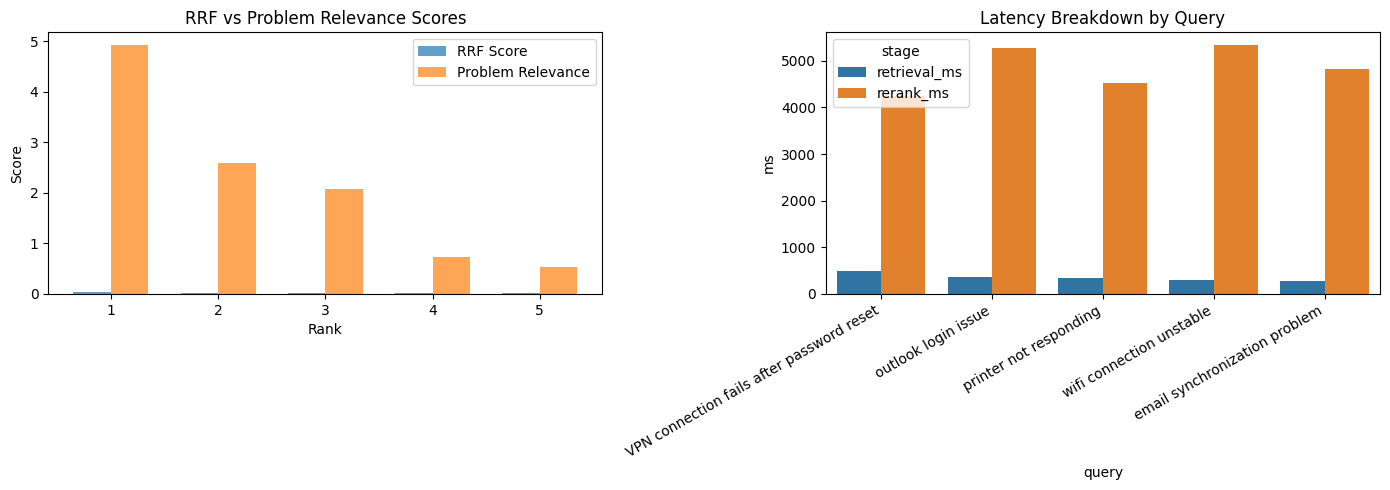

In [83]:
# ============================================================
# CELL 20 — VISUALIZE RERANK SCORES
# ============================================================

log_step("VISUALIZATION")

if not results.empty and "rerank_score" in results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    plot_df = results.head(CONFIG["rerank_top_k"]).copy()
    plot_df["label"] = plot_df["chunk_id"].str.slice(-20)

    ax = axes[0]
    x = np.arange(len(plot_df))
    w = 0.35
    ax.bar(x - w / 2, plot_df["rrf_score"], w, label="RRF Score", alpha=0.7)
    ax.bar(x + w / 2, plot_df["rerank_score"], w, label="Problem Relevance", alpha=0.7)
    ax.set_xlabel("Rank")
    ax.set_ylabel("Score")
    ax.set_title("RRF vs Problem Relevance Scores")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["final_rank"] if "final_rank" in plot_df.columns else plot_df.index)
    ax.legend()

    ax = axes[1]
    if not benchmark_df.empty:
        bp = sns.barplot(data=benchmark_df.melt(
            id_vars=["query"],
            value_vars=["retrieval_ms", "rerank_ms"],
            var_name="stage", value_name="ms"
        ), x="query", y="ms", hue="stage", ax=ax)
        ax.set_title("Latency Breakdown by Query")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    else:
        ax.text(0.5, 0.5, "No benchmark data", ha="center", va="center", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()
else:
    print("No results to visualize.")

In [84]:
# ============================================================
# CELL 21 — FINAL RERANKING REPORT
# ============================================================

log_step("FINAL RERANKING REPORT")

print(f"Pipeline Components:")
print(f"  FAISS Index:       {index.ntotal:,} vectors (dim={index.d})")
print(f"  BM25 Corpus:       {len(bm25_tokens):,} documents")
print(f"  Metadata:          {len(metadata_df):,} rows")
print(f"  Solution Lookup:   {len(solution_map):,} documents")
print(f"  Embedding Model:   {CONFIG['embedding_model_name']}")
print(f"  CrossEncoder:      {CONFIG['cross_encoder_model_name']}")
print(f"  Device:            {embedding_model.device}")

print(f"\nPipeline Parameters:")
print(f"  FAISS Top-K:       {CONFIG['top_k_faiss']}")
print(f"  BM25 Top-K:        {CONFIG['top_k_bm25']}")
print(f"  RRF Constant (k):  {CONFIG['rrf_k']}")
print(f"  Hybrid Top-K:      {CONFIG['hybrid_top_k']}")
print(f"  Rerank Top-K:      {CONFIG['rerank_top_k']}")

print(f"\nBenchmark Results:")
if not benchmark_df.empty:
    print(f"  Avg Retrieval:     {benchmark_df['retrieval_ms'].mean():.1f}ms")
    print(f"  Avg Fetch:         {benchmark_df['fetch_ms'].mean():.1f}ms")
    print(f"  Avg Rerank:        {benchmark_df['rerank_ms'].mean():.1f}ms")
    print(f"  Avg Total:         {benchmark_df['total_ms'].mean():.1f}ms")

print(f"\nExports:")
print(f"  Results:           {CONFIG['export_path']}")
print(f"  Benchmarks:        {CONFIG['benchmark_export_path']}")
print(f"  Solution Lookup:   {CONFIG['solution_lookup_path']}")

print(f"\n{'=' * 60}")
print(f"  PROBLEM-RELEVANCE RERANKING COMPLETE")
print(f"  Architecture: Hybrid Retrieval → Fetch Solutions By ID → CrossEncoder → Top-10")
print(f"  Pipeline ready for notebook 09 (RAG Generation)")
print(f"{'=' * 60}")


  FINAL RERANKING REPORT
Pipeline Components:
  FAISS Index:       109,875 vectors (dim=384)
  BM25 Corpus:       109,875 documents
  Metadata:          109,875 rows
  Solution Lookup:   108,421 documents
  Embedding Model:   paraphrase-multilingual-MiniLM-L12-v2
  CrossEncoder:      cross-encoder/ms-marco-MiniLM-L-12-v2
  Device:            cpu

Pipeline Parameters:
  FAISS Top-K:       40
  BM25 Top-K:        40
  RRF Constant (k):  60
  Hybrid Top-K:      30
  Rerank Top-K:      5

Benchmark Results:
  Avg Retrieval:     357.6ms
  Avg Fetch:         8.3ms
  Avg Rerank:        4846.9ms
  Avg Total:         5212.8ms

Exports:
  Results:           ../../evaluation_v2/reranking_results_v2.csv
  Benchmarks:        ../../evaluation_v2/benchmarks/reranking_latency_v2.csv
  Solution Lookup:   ../../parquet_exports_v2/solution_lookup_v2.parquet

  PROBLEM-RELEVANCE RERANKING COMPLETE
  Architecture: Hybrid Retrieval → Fetch Solutions By ID → CrossEncoder → Top-10
  Pipeline ready for notebo